### **Imports** 

In [1]:
import numpy as np
import sys, os
from autograd import grad, hessian
import autograd.numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
from utils import *
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.colors as mcolors


### **Using Support Vector Machines for Nonlinear Classification** <br>


In [2]:
#Load the data 
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot19f.csv'
data_dir = data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22f.csv'

data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only the columns I want to have the format: 
# 0:Met[Zsun], 1:Age[Gyr], 2:Rp[Rsun], 3:Vinf[km/s], 4:Mass1[MSUN], 5:Mass2[MSUN], 6:Label
data = data_loaded[:, [0, 1, 2, 3, 4, 5, 8]]

y_data = data[:,-1].astype(np.int64)
x_data = data[:, 1:-1]

#Make the data into desired shape for sklearn (npoints, ndim)
# x_data = data[:,]
# y_data = labels

#Feature transform: log the x-data
x_data[:, 0] = np.log10(x_data[:, 0]) # log ages
x_data[:, 2] = np.log10(x_data[:, 2]) # log vinfs
y_data[y_data < 0] = 3 #replace locally the meaning of label -1

print(np.shape(x_data), np.shape(y_data))

#Split into training and testing using 70% - 30% split
random_state = 42
X_data_og = x_data
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.30, stratify = y_data, random_state=random_state)

X_train_og, X_test_og = X_train, X_test

#Standard normalize the training data and use the mean and std to normalize the testing data
svc_scaler = StandardScaler().fit(X_train)
X_train = svc_scaler.transform(X_train)
X_test = svc_scaler.transform(X_test)

print("Training set ", np.shape(X_train), np.shape(y_train))
print("Testing set ", np.shape(X_test), np.shape(y_test))

(21473, 5) (21473,)
Training set  (15031, 5) (15031,)
Testing set  (6442, 5) (6442,)


For the kernel in the `SVM`, I chose the `Radial Basis Function (RBF)` kernel because it offers flexibility in shaping the decision boundary. This kernel has two parameters: `C` and `gamma`. The parameter `C` acts as an inverse regularizer, where lower values of `C` lead to simpler decision boundaries. Gamma controls how much influence a single training example has. Since I'm unsure which values of `C` and `gamma` to begin with, I use `Grid Search` to find the optimal combination of these parameters. Additionally, I have addressed class imbalances by using the `class_weight` parameter, which assigns higher weights to the underrepresented classes.


In [3]:
#Performing one-versus-rest and grid search

parameters = {'kernel':[('rbf')], 'C':[0.01, 0.1, 1, 10, 100, 1000], 'gamma':[0.001, 0.01, 0.1, 1, 10]}

svc = svm.SVC(decision_function_shape='ovr', class_weight='balanced')
svc = GridSearchCV(svc, parameters, scoring = 'balanced_accuracy')
svc.fit(X_train, y_train)


GridSearchCV(estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': [0.001, 0.01, 0.1, 1, 10],
                         'kernel': ['rbf']},
             scoring='balanced_accuracy')

In [4]:
#--- Checking the results from the gridsearch ---#
results = pd.DataFrame(svc.cv_results_)
print(results[[ 'params']])
print(svc.best_params_)

                                          params
0   {'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}
1    {'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
2     {'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}
3       {'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}
4      {'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}
5    {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
6     {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
7      {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
8        {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
9       {'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
10     {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
11      {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
12       {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
13         {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
14        {'C': 1, 'gamma': 10, 'kernel': 'rbf'}
15    {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
16     {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
17      {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
18        {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
19       {'C': 10, '

In [5]:
#---Checking the accuracy of the model on the testing data set---#

best_model_svc = svc.best_estimator_
y_pred = best_model_svc.predict(X_test)

print("Test Accuracy: {:.3f}%".format(accuracy_score(y_test, y_pred)*100))
print("Test Balanced Accuracy: {:.3f}%".format(balanced_accuracy_score(y_test, y_pred)*100))

# print(X_test[y_pred != y_test])

Test Accuracy: 94.908%
Test Balanced Accuracy: 93.777%


In [5]:
def N_svc_gridsearch_plotter(X_train, y_train, X_test, y_test, svc, svc_scaler,feature_idx=(0, 1), fixed_values={}, labels = []):

    # Step 1: Filter train and test data based on fixed_values
    
    train_mask = np.all(np.array([np.isclose(X_train[:, k], v, rtol=0.09) for k, v in fixed_values.items()]), axis=0)
    test_mask = np.all(np.array([np.isclose(X_test[:, k], v, rtol=0.09) for k, v in fixed_values.items()]), axis=0)


    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    #--- Plot predictions ---#
    
    # Create a mesh grid
    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train[:, feature_idx[0]].min() - 0.1, X_train[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train[:, feature_idx[1]].min() - 0.1, X_train[:, feature_idx[1]].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    print(x_min, x_max)
    # Step 3: Construct full-dimensional input space for predictions
    X_grid = np.zeros((xx.ravel().shape[0], X_train.shape[1]))
    X_grid[:, feature_idx[0]] = xx.ravel()
    X_grid[:, feature_idx[1]] = yy.ravel()

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_grid[:, k] = v  

    #transform the data
    X_grid_scaled = svc_scaler.transform(X_grid)
 
    #Predict labels for meshgrid
    best_model = svc.best_estimator_
    Z = best_model.predict(X_grid_scaled)
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=Z.min(), vmax=Z.max())  # Normalize colors

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

    #--- Overplot the data ---#

    plt.scatter(X_train_filtered[:, feature_idx[0]], X_train_filtered[:, feature_idx[1]],  c=y_train_filtered,  cmap='coolwarm',  edgecolor="k", marker='o', label = 'Train' )
    plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap='coolwarm', edgecolor="k" , marker='x', label = 'Test')

    #--- Plot settings ---#

    plt.title(f"SVM: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun")
    plt.xlabel(f" {labels[0]}")
    plt.ylabel(f" {labels[1]}")
    plt.legend()
    plt.show()

In [6]:
masses = X_data_og[2:,:]
masses[1, :] = masses[0, :] / masses[1, :]
unique_rows = np.unique(masses, axis=1)


-5.497940008672037 0.42637334793826853


/var/folders/4h/5kpc_p3153q1gx8btc9x_3mc0000gn/T/ipykernel_79451/2537996721.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap='coolwarm', edgecolor="k" , marker='x', label = 'Test')


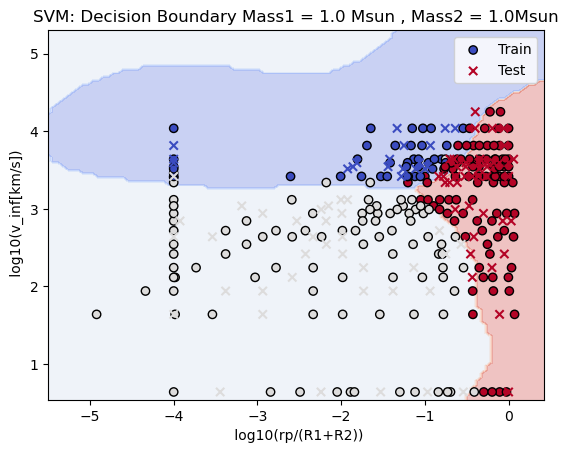

In [7]:
# unique_rows = unique_rows.T
unique_rows = np.array([[1.0,1.0]])
for unique in unique_rows:
    Mass1 = unique[0]
    Mass2 = unique[1]
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = ['log10(rp/(R1+R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    N_svc_gridsearch_plotter(X_train_og, y_train, X_test_og ,y_test, svc, svc_scaler,feature_idx=(0, 1), fixed_values={2: Mass1, 3: Mass1/Mass2}, labels = labels)

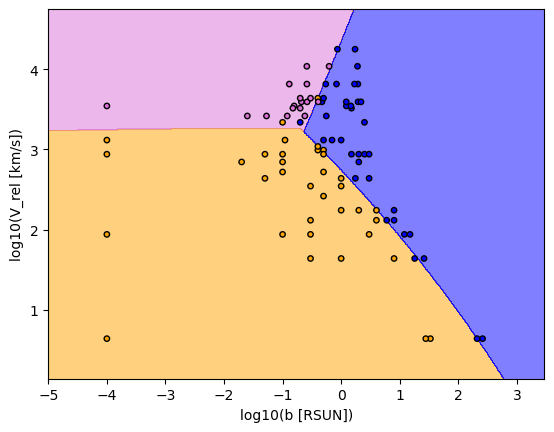

In [7]:
#---Visualize the decision boundary---#
# f = svc_gridsearch_plotter(x_data, y_data, svc, svc_scaler, X_test_og, y_test)
# plt.show()



In [52]:
def svc_gridsearch_plotter(x_data, y_data, svc, svc_scaler):

    #--- Plot predictions ---#
    
    # Create a mesh grid
    x_min, x_max = x_data[:,0].min() -1, x_data[:,0].max()+1
    y_min, y_max = x_data[:,1].min() - 0.5, x_data[:,1].max() +0.5

    xx, yy = np.meshgrid(np.arange(x_min,  x_max, 0.01),
                        np.arange(y_min,  y_max, 0.01))

    #transform the data
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    X_grid_scaled = svc_scaler.transform(X_grid)

    # Predict classes for each point in the grid
    best_model = svc.best_estimator_
    Z = best_model.predict(X_grid_scaled)
    Z = Z.reshape(xx.shape)


    class_colors = ['orchid', 'orange', 'blue']
    display = DecisionBoundaryDisplay(xx0=xx, xx1=yy, response=Z, xlabel = "log10(b) [RSUN]", ylabel ="log10(V_rel) [km/s]")
    display.plot(cmap=plt.cm.colors.ListedColormap(class_colors), alpha = 0.5)  # Apply custom colors


    #--- Overplot the data ---#

    # Define conditions and corresponding colors
    conditions = [y_data == 0., y_data == 1., y_data == 2.]
    choices = ['orchid', 'orange', 'blue']

    # Apply mapping
    colors = np.select(conditions, choices, default = 'gray').flatten()

    plt.scatter(x_data[:,0],x_data[:,1],  c=colors, s = 15,  edgecolor="black", zorder = 2)

    #--- Plot settings ---#

    plt.ylabel("log10(V_rel [km/s])")
    plt.xlabel("log10(b [RSUN])")

    plt.xlim(-2, 1)
    plt.ylim(2, 4)
    # plt.scatter(np.log10(2), np.log10(349.23590063), color = 'green', s = 20, alpha = 0.5, label = '57')
    # plt.scatter(np.log10(0.1681), np.log10(18072.95785737), color = 'red', s = 20, alpha = 0.5, label = '15610')
    # plt.scatter(np.log10(0.1572), np.log10(602.43192858), color = 'purple', s = 20, alpha = 0.5, label = '15496')

    plt.scatter(np.log10(0.4), np.log10(4365.44875782), color = 'green', s = 40, alpha = 0.8, label = '144', zorder = 1)
    plt.scatter(np.log10(0.2), np.log10(2182.72437891), color = 'red', s = 40, alpha = 0.8, label = '5576', zorder = 1)
    plt.scatter(np.log10(0.5), np.log10(982.22597051), color = 'purple', s = 40, alpha = 0.8, label = '30', zorder = 1)
    plt.scatter(np.log10(0.406), np.log10(3928.90388204), color = 'black', s = 40, alpha = 0.8, label = '2056', zorder = 1)
    plt.legend()
    
    return display

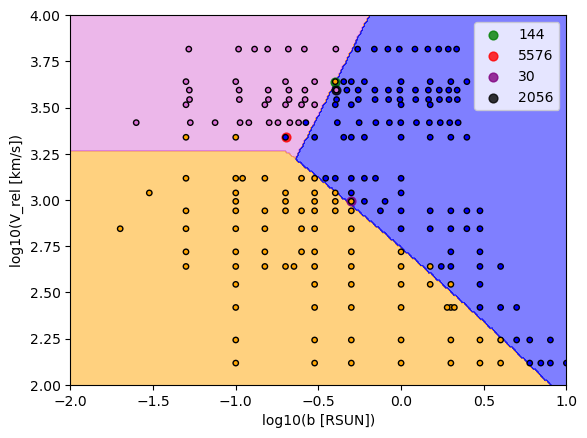

In [53]:
#---Visualize the decision boundary---#
f = svc_gridsearch_plotter(x_data, y_data, svc, svc_scaler)
plt.show()

**Part 3: Predicting the mass loss of a stellar collision** <br> 
For the third part, I have expanded the dataset to include the fraction of mass lost during the stellar collision. My first step will be to visualize the data to assess whether it is separable.

(4, 796)
(796, 3)


/var/folders/c4/n_2j1jhn4v73txjwq7zgfrxh0000gn/T/ipykernel_45995/2554394915.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


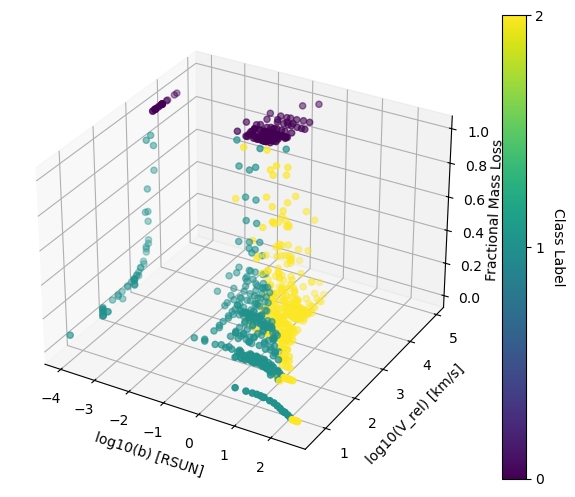

In [43]:
#Load the data 
data = np.loadtxt( 'data_dm.csv',delimiter = ',', skiprows=1)
print(np.shape(data))

#x-data includes b, vinf and the class labels 
#y-data includes the fractional mass loss 
x_data = data[:-1,].T
y_data = data[-1:,].T.ravel()
print(np.shape(x_data))

#Feature transform: log the x-data
x_data[:,0][x_data[:,0] <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data[:,1][x_data[:,1] <= 0] = 1e-4 

x_data[:,0] = np.log10(x_data[:,0])
x_data[:,1] = np.log10(x_data[:,1])

f = data_3d_plotter(x_data, y_data)
f.set_size_inches(6,5)
f.show()



From the figure, we can see that the class label is strongly correlated with the fractional mass loss. This makes sense, as a label of 0 indicates that both stars were destroyed in the collision, resulting in a 100% mass loss. This correlation motivates me to incorporate the labels as an additional input feature for the model. However, I have learned that ML models should not be trained on labels. Therefore, I implemented a `one-hot encoder` to transform the labels into vectors, effectively adding two dimensions to my input data. I once again perform `GridSearchCV` to see which values of `C` and `gamma` are the most optimal, and I add a `sigmoid` kernel and its corresponding `coeff0` parameter in the grid search. 

In [44]:
#Load the data 
data = np.loadtxt( 'data_dm.csv',delimiter = ',', skiprows=1)

print(np.shape(data))

#x-data includes b, vinf and the class labels 
#y-data includes the fractional mass loss 
x_data = data[:-1,].T
y_data = data[-1:,].T.ravel()

print(np.shape(x_data))

#Feature transform: log the x-data
x_data[:,0][x_data[:,0] <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data[:,1][x_data[:,1] <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf

x_data[:,0] = np.log10(x_data[:,0])
x_data[:,1] = np.log10(x_data[:,1])

encoder = OneHotEncoder()
column_to_encode = x_data[:,2][:,np.newaxis]
encoded = encoder.fit_transform(column_to_encode).toarray()

#Concatenate the encoded column with the rest of the data
x_data_encoded = np.hstack((x_data[:, :2], encoded))

#Split into training and testing 

random_state = 50
X_train, X_test, y_train, y_test = train_test_split(x_data_encoded, y_data, test_size=0.30, random_state=random_state)

svr_scaler = StandardScaler().fit(X_train)
X_train = svr_scaler.transform(X_train)
X_test = svr_scaler.transform(X_test)

print(np.shape(X_train), np.shape(y_train))
print(np.shape(X_test), np.shape(y_test))

#Performing one-versus-rest 

parameters = {'kernel':['rbf','sigmoid'], 'C':[ 0.1, 1, 10, 100], 'gamma':[0.01, 0.1, 1], 'coef0':[0.01, 0.1, 1]}

svr = svm.SVR()
svr = GridSearchCV(svr, parameters, scoring = 'neg_mean_squared_error', cv = 5)

svr.fit(X_train, y_train)

(4, 796)
(796, 3)
(557, 5) (557,)
(239, 5) (239,)


GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100], 'coef0': [0.01, 0.1, 1],
                         'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf', 'sigmoid']},
             scoring='neg_mean_squared_error')

In [23]:
#--- Checking the results from the gridsearch ---#
#Commented out for the pdf
# results_svr = pd.DataFrame(svr.cv_results_)
# best_model_svr = svr.best_estimator_
# print(results_svr[['params', 'mean_test_score', 'std_test_score']])
# print(svr.best_params_)

In [45]:
#---Checking the accuracy of the model on the testing data set---#
y_pred = best_model_svr.predict(X_test)
print("MSE: {:.3f}%".format(mean_squared_error(y_test, y_pred)*100))

MSE: 1.056%


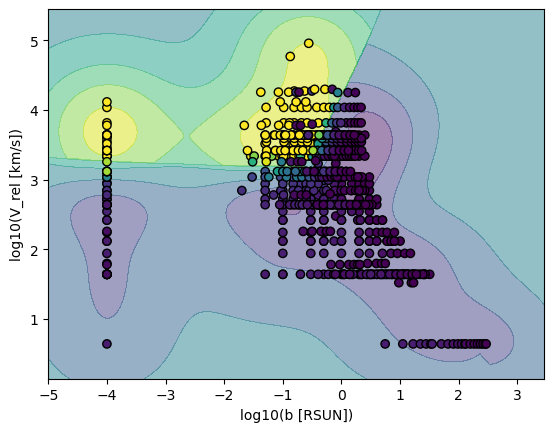

In [46]:
#--- Visualize the decision boundaries ---#
#color bar here indicates fractional mass loss from 0 (purple) to 1(yellow)
svr_gridsearch_plotter(x_data_encoded, x_data, y_data, svc, svc_scaler, svr, svr_scaler, encoder)

I think this SVR does pretty well at reaching simple, yet informative decision boundaries. Adding the hot encoding decreased the MSE error by an order of magnitude. 

## **Next Steps** <br>

My next steps involve expanding the SPH simulation dataset to ensure the input data for the model is more spread out. On the ML side, I believe it will be beneficial to explore methods for making these models physics-informed, as there are theoretical predictions for the classification task. I also plan to delve deeper into understanding which features are most valuable for the regression problem and investigate whether there are other input features from the SPH simulations that could help the model improve as more data is added. Finally, the main goal of a much larger endevour is to train a classifier in multi dimensional space, with stars of different masses and mass ratios. 